# Lesson 1.6 — 1D Linear Advection

## The Conveyor Belt Analogy

Imagine a dye blob placed on a conveyor belt moving at constant speed $c$. The blob moves
rigidly to the right without changing shape. The **linear advection equation** describes
exactly this — a scalar quantity $u$ transported by a constant velocity $c$:

$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$

The exact solution is simply: $u(x, t) = u_0(x - ct)$ — the initial profile $u_0$ shifts
to the right at speed $c$. No deformation, no diffusion.

This is the simplest PDE in CFD and the best test bed for numerical schemes.

---

## Discretizing the Advection Equation

Using time index $n$ and space index $i$, the FTBS (Forward in Time, Backward in Space) scheme:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} + c \frac{u_i^n - u_{i-1}^n}{\Delta x} = 0$$

Solving for $u_i^{n+1}$:

$$u_i^{n+1} = u_i^n - \nu (u_i^n - u_{i-1}^n)$$

where $\nu = c \Delta t / \Delta x$ is the **CFL number** (Courant-Friedrichs-Lewy).

---

## The CFL Condition — The Most Important Stability Criterion in CFD

The scheme is **stable** only when $0 \leq \nu \leq 1$, i.e.:

$$\Delta t \leq \frac{\Delta x}{c}$$

Physical interpretation: the time step must be small enough that information cannot travel
more than one grid cell per step. If $\nu > 1$, the wave "jumps over" the stencil and the
solution blows up.

Mnemonic: **CFL = how many cells does the wave travel per time step?** Keep it $\leq 1$.

---

## Common Schemes Compared

| Scheme | Formula | Order (space×time) | Stability | Behaviour |
|--------|---------|-------------------|-----------|----------|
| FTFS (upwind, wrong direction) | $u_i^n - \nu(u_{i+1}^n - u_i^n)$ | 1×1 | Unstable for $c>0$ | Blows up |
| FTBS (upwind) | $u_i^n - \nu(u_i^n - u_{i-1}^n)$ | 1×1 | Stable ($0\leq\nu\leq1$) | Diffusive |
| FTCS (central) | $u_i^n - \frac{\nu}{2}(u_{i+1}^n - u_{i-1}^n)$ | 2×1 | Unconditionally unstable | Blows up |
| Lax-Wendroff | (two-step) | 2×2 | $\nu\leq1$ | Dispersive (wiggles) |


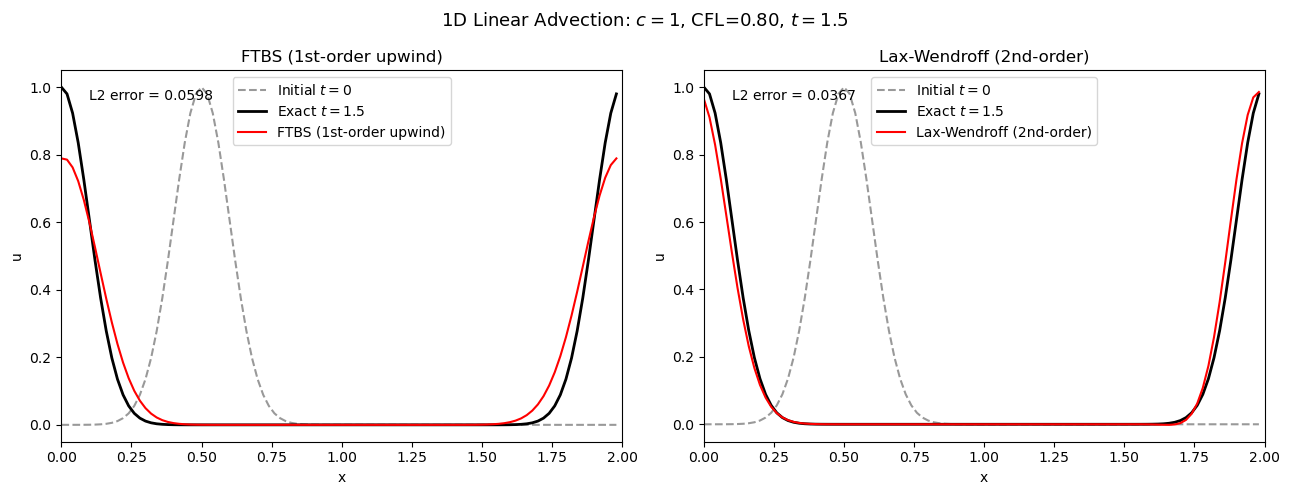

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def advect(u0, c, dx, dt, nt, scheme='upwind'):
    """Advect initial condition u0 using the specified scheme."""
    u = u0.copy()
    nu = c * dt / dx
    
    for _ in range(nt):
        if scheme == 'upwind':
            # FTBS: first-order upwind
            u[1:] = u[1:] - nu * (u[1:] - u[:-1])
            u[0]  = u[0]  - nu * (u[0]  - u[-1])   # periodic BC
        elif scheme == 'lax_wendroff':
            # Second-order accurate in space and time
            u_new = np.zeros_like(u)
            u_new[1:-1] = (u[1:-1]
                           - nu/2 * (u[2:] - u[:-2])
                           + nu**2/2 * (u[2:] - 2*u[1:-1] + u[:-2]))
            u_new[0]  = (u[0]
                         - nu/2 * (u[1] - u[-1])
                         + nu**2/2 * (u[1] - 2*u[0] + u[-1]))
            u_new[-1] = (u[-1]
                         - nu/2 * (u[0] - u[-2])
                         + nu**2/2 * (u[0] - 2*u[-1] + u[-2]))
            u = u_new
    return u

# Setup
N  = 100
L  = 2.0
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)
c  = 1.0
dt = 0.8 * dx / c   # CFL = 0.8
T  = 1.5            # simulate until t=1.5
nt = int(T / dt)

# Initial condition: Gaussian bump
u0 = np.exp(-((x - 0.5)**2) / 0.02)

# Exact solution shifts the bump by c*T
x_exact = (x - c*T) % L
u_exact = np.exp(-((x_exact - 0.5)**2) / 0.02)

u_upwind = advect(u0, c, dx, dt, nt, 'upwind')
u_lw     = advect(u0, c, dx, dt, nt, 'lax_wendroff')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, u_num, label in zip(axes, [u_upwind, u_lw], ['FTBS (1st-order upwind)', 'Lax-Wendroff (2nd-order)']):
    ax.plot(x, u0,      'k--', alpha=0.4, label='Initial $t=0$')
    ax.plot(x, u_exact, 'k-',  linewidth=2, label='Exact $t=1.5$')
    ax.plot(x, u_num,   'r-',  linewidth=1.5, label=label)
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.set_title(label)
    ax.legend()
    ax.set_xlim(0, 2)
    l2_err = np.sqrt(np.mean((u_num - u_exact)**2))
    ax.text(0.05, 0.92, f'L2 error = {l2_err:.4f}', transform=ax.transAxes)

plt.suptitle(f'1D Linear Advection: $c=1$, CFL={c*dt/dx:.2f}, $t={T}$', fontsize=13)
plt.tight_layout()
plt.show()

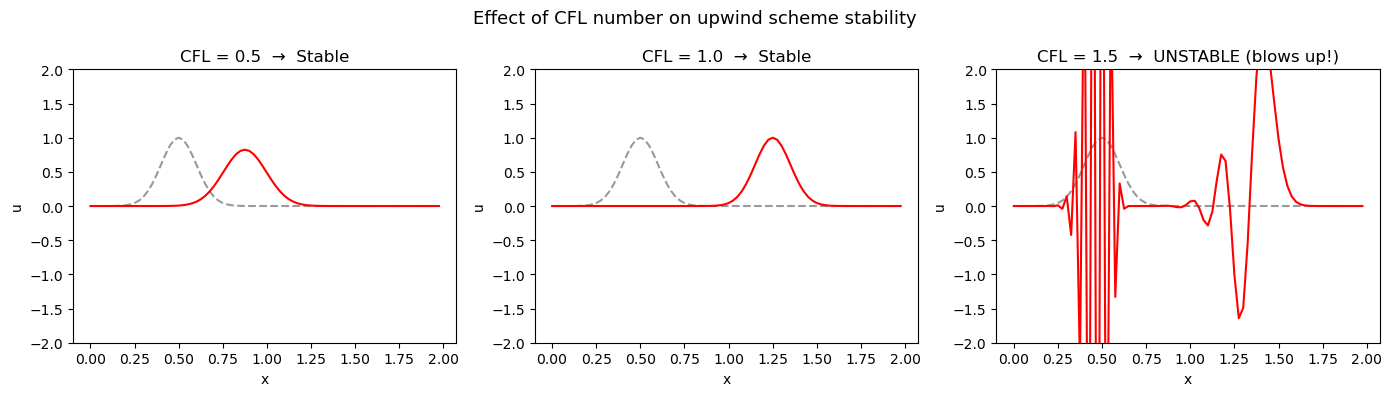

CFL > 1: unstable. The wave travels more than one cell per time step → blow-up.


In [2]:
# Demonstrate CFL instability: what happens when CFL > 1?
N  = 80
dx = 2.0 / N
x  = np.linspace(0, 2, N, endpoint=False)
c  = 1.0
u0 = np.exp(-((x - 0.5)**2) / 0.02)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cfl_values = [0.5, 1.0, 1.5]
nt_stable = 30

for ax, cfl in zip(axes, cfl_values):
    dt_cfl = cfl * dx / c
    u = u0.copy()
    blown = False
    for _ in range(nt_stable):
        u_new = u.copy()
        u_new[1:] = u[1:] - cfl * (u[1:] - u[:-1])
        u_new[0]  = u[0]  - cfl * (u[0]  - u[-1])
        u = u_new
        if np.max(np.abs(u)) > 10:
            blown = True
            break
    
    ax.plot(x, u0, 'k--', alpha=0.4, label='Initial')
    ax.plot(x, u,  'r-', linewidth=1.5)
    status = 'UNSTABLE (blows up!)' if blown else 'Stable'
    ax.set_title(f'CFL = {cfl}  →  {status}')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.set_ylim(-2, 2)

plt.suptitle('Effect of CFL number on upwind scheme stability', fontsize=13)
plt.tight_layout()
plt.show()

print("CFL > 1: unstable. The wave travels more than one cell per time step → blow-up.")

## Key Takeaways

- The linear advection equation $\partial_t u + c \partial_x u = 0$ is the canonical test problem for CFD schemes.
- The exact solution is pure translation: $u(x,t) = u_0(x - ct)$.
- **CFL condition**: $\nu = c\Delta t / \Delta x \leq 1$ for stability of explicit schemes.
- First-order upwind (FTBS): stable but diffusive — smears sharp features.
- Lax-Wendroff: second-order accurate but dispersive — generates oscillations (Gibbs phenomenon).
- No scheme is perfect. The trade-off between diffusion and dispersion is a central theme in CFD.

---

**Next**: Lesson 1.7 — 1D Diffusion Equation: explicit vs. implicit, stability, Fourier analysis.
